In [156]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
from sklearn import linear_model
import seaborn as sns
import random 
import statistics 
import math 
import scipy as sc
from scipy.stats import chisquare
from collections import Counter

random.seed(42)

## Task 7

In [157]:
def continous_time_state_distribution(n, Q):
    survival_distribution = []
    states = []

    for _ in range(n):
        state = 0 
        survivaltime = 0
        while state != 4:
            transition_time = np.random.exponential(1/-Q[state][state])
            survivaltime += transition_time

            prop_list = [-q / Q[state][state] for q in Q[state][state+1:]]
            state = np.random.choice(np.arange(state+1, 5), p=prop_list)

        survival_distribution.append(survivaltime)

    mean_survival_time = np.mean(survival_distribution)

    return survival_distribution, mean_survival_time

In [158]:
n_women = 1000
Q = np.array([
    [-0.0085,  0.005,  0.0025, 0,      0.001],
    [0,      -0.014,   0.005,  0.004,  0.005],
    [0,       0,      -0.008,  0.003,  0.005],
    [0,       0,       0,     -0.009,  0.009],
    [0,       0,       0,      0,      0]
])

survival_distribution, mean_survival_time = continous_time_state_distribution(n_women, Q)

In [159]:
mean_survival_time

np.float64(263.94466939741966)

Text(0.5, 1.0, 'Lifetime Distribution of Women after Surgery')

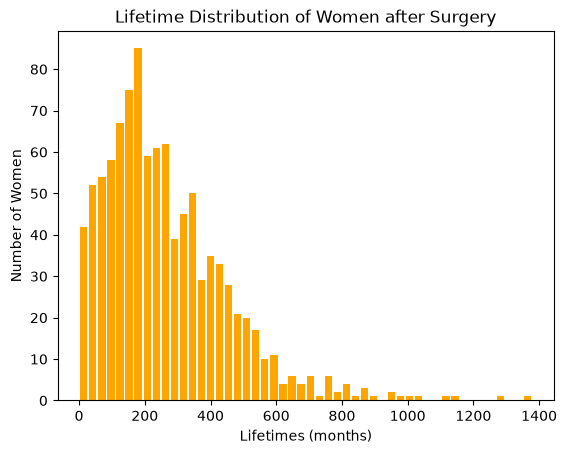

In [160]:
plt.hist(survival_distribution, bins=50, rwidth=0.8, color="orange")
plt.xlabel('Lifetimes (months)')
plt.ylabel('Number of Women')
plt.title('Lifetime Distribution of Women after Surgery')

In [168]:
std = np.std(survival_distribution)
confidence_interval = (mean_survival_time - 1.96 * std / np.sqrt(n_women), mean_survival_time + 1.96 * std / np.sqrt(n_women))
confidence_interval, mean_survival_time, std

((np.float64(252.22523276253224), np.float64(275.6641060323071)),
 np.float64(263.94466939741966),
 np.float64(189.08220745032344))

In [169]:
def continous_time_state_distribution_distant(n, Q):
    survival_distribution = []
    distant_after_t = []

    for _ in range(n):
        state = 0 
        survival_time = 0
        while state != 4:
            transition_time = np.random.exponential(1/-Q[state][state])
            survival_time += transition_time

            prop_list = [-q / Q[state][state] for q in Q[state][state+1:]]
            state = np.random.choice(np.arange(state+1, 5), p=prop_list)

            if (state in [2,3]) & (survival_time > 30.5):
                distant_after_t.append(True)


        survival_distribution.append(survival_time)

    distant_fraction = sum(distant_after_t) / n
    mean_survival_time = np.mean(survival_distribution)

    return survival_distribution, distant_fraction, mean_survival_time

In [ ]:
survival_distribution, distant_fraction, mean_survival_time = continous_time_state_distribution_distant(n_women, Q)

In [174]:
print(f"Distant fraction after 30.5 months: {distant_fraction}")

Distant fraction after 30.5 months: 0.799
